<a href="https://colab.research.google.com/github/luccasnn/chatbot-rag/blob/main/chatbot_rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install langchain langchain-community faiss-cpu sentence-transformers pypdf langchain-huggingface langchain-text-splitters -q

import os
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from transformers import pipeline
import torch

print("dependências instaladas!")
print("GPU:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.9/343.9 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


/tmp/ipykernel_4740/3687956349.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


dependências instaladas!
GPU: True


In [4]:
# baixa um pdf público para usar como base de conhecimento
!wget -q "https://arxiv.org/pdf/1706.03762.pdf" -O documento.pdf

import os
print("tamanho do arquivo:", os.path.getsize("documento.pdf"), "bytes")

# carrega e divide o pdf em pedaços
loader = PyPDFLoader("documento.pdf")
paginas = loader.load()

print(f"total de páginas: {len(paginas)}")
print(f"\nexemplo de conteúdo da página 1:")
print(paginas[0].page_content[:300])

tamanho do arquivo: 2215244 bytes
total de páginas: 15

exemplo de conteúdo da página 1:
Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.com
Noam Shazeer∗
Google Brain
noam@google.com
Niki Par


In [7]:
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(paginas)

print(f"total de chunks: {len(chunks)}")
print(f"\nexemplo de chunk:")
print(chunks[0].page_content)

total de chunks: 93

exemplo de chunk:
Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.com
Noam Shazeer∗
Google Brain
noam@google.com
Niki Parmar∗
Google Research
nikip@google.com
Jakob Uszkoreit∗
Google Research
usz@google.com
Llion Jones∗
Google Research
llion@google.com
Aidan N. Gomez∗ †
University of Toronto
aidan@cs.toronto.edu


In [8]:
# transforma cada chunk em vetor numérico
print("criando embeddings — pode demorar 1-2 minutos...")
embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')

# cria o banco vetorial com faiss
vectorstore = FAISS.from_documents(chunks, embeddings)
print("banco vetorial criado!")
print(f"total de vetores: {vectorstore.index.ntotal}")

criando embeddings — pode demorar 1-2 minutos...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

banco vetorial criado!
total de vetores: 93


In [10]:
# carrega um modelo leve de qa
print("carregando modelo de resposta...")
qa_pipeline = pipeline(
    "question-answering",
    model="deepset/roberta-base-squad2",
    device=0
)

print("modelo carregado!")

carregando modelo de resposta...


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaForQuestionAnswering LOAD REPORT from: deepset/roberta-base-squad2
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

modelo carregado!


In [11]:
# função que busca chunks relevantes e responde a pergunta
def perguntar(pergunta, k=3):
    # busca os k chunks mais relevantes no banco vetorial
    docs_relevantes = vectorstore.similarity_search(pergunta, k=k)

    # junta os chunks em um contexto único
    contexto = " ".join([doc.page_content for doc in docs_relevantes])

    # passa contexto + pergunta pro modelo
    resposta = qa_pipeline(question=pergunta, context=contexto)

    print(f"pergunta: {pergunta}")
    print(f"resposta: {resposta['answer']}")
    print(f"confiança: {resposta['score']:.3f}")
    print("---")
    return resposta

# testa com perguntas sobre o paper
perguntar("What is the Transformer architecture?")
perguntar("How many attention heads are used?")
perguntar("What datasets were used for training?")

pergunta: What is the Transformer architecture?
resposta: stacked self-attention and point-wise, fully
connected layers
confiança: 0.162
---
pergunta: How many attention heads are used?
resposta: <pad>
confiança: 0.017
---
pergunta: What datasets were used for training?
resposta: WMT 2014 English-German
confiança: 0.202
---


{'score': 0.20150360465049744,
 'start': 1342,
 'end': 1365,
 'answer': 'WMT 2014 English-German'}

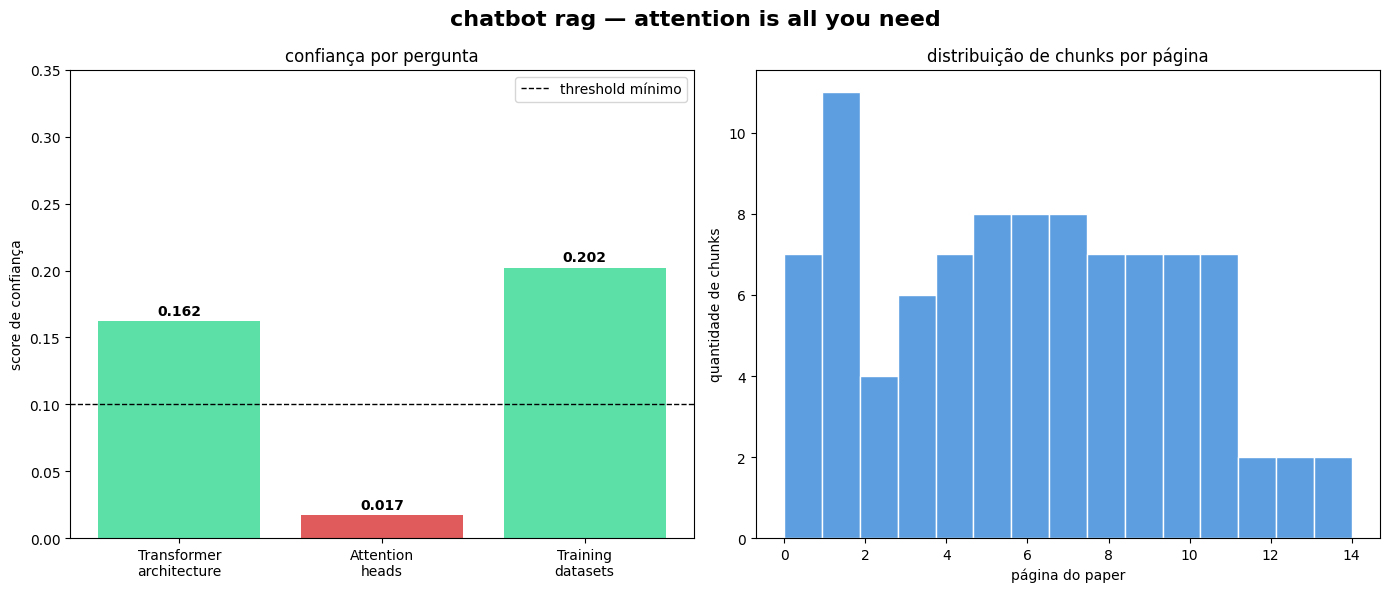

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('chatbot rag — attention is all you need', fontsize=16, fontweight='bold')

# 1. confiança das respostas
perguntas = ['Transformer\narchitecture', 'Attention\nheads', 'Training\ndatasets']
confianças = [0.162, 0.017, 0.202]
cores = ['#5ce0a8' if c > 0.1 else '#e05c5c' for c in confianças]

axes[0].bar(perguntas, confianças, color=cores)
axes[0].axhline(y=0.1, color='black', linestyle='--', linewidth=1, label='threshold mínimo')
axes[0].set_title('confiança por pergunta')
axes[0].set_ylabel('score de confiança')
axes[0].set_ylim(0, 0.35)
axes[0].legend()
for i, v in enumerate(confianças):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

# 2. distribuição dos chunks por página
paginas_chunks = [chunk.metadata.get('page', 0) for chunk in chunks]
axes[1].hist(paginas_chunks, bins=15, color='#5c9ee0', edgecolor='white')
axes[1].set_title('distribuição de chunks por página')
axes[1].set_xlabel('página do paper')
axes[1].set_ylabel('quantidade de chunks')

plt.tight_layout()
plt.savefig('chatbot_rag.png', dpi=150, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('chatbot_rag.png')

In [13]:
!pip install gradio -q

import gradio as gr

def chatbot(pergunta):
    docs_relevantes = vectorstore.similarity_search(pergunta, k=3)
    contexto = " ".join([doc.page_content for doc in docs_relevantes])
    resposta = qa_pipeline(question=pergunta, context=contexto)
    return f"**Resposta:** {resposta['answer']}\n\n**Confiança:** {resposta['score']:.3f}"

interface = gr.Interface(
    fn=chatbot,
    inputs=gr.Textbox(label="Faça uma pergunta sobre o paper"),
    outputs=gr.Markdown(label="Resposta"),
    title="Chatbot RAG — Attention is All You Need",
    description="Faça perguntas em inglês sobre o paper que inventou a arquitetura Transformer"
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a82cd464da0c5d1c90.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
